# 06b — ModernBERT Full-Data Training

**Goal**: Train `ModernBERT-base` on the same **500K stratified subsample** using the same best config from NB05, with the epoch cap informed by RoBERTa's scouting run (NB06a).

**RoBERTa scouting results (NB06a)**:
- Peaked at **epoch 3** (macro-F1 = 0.725)
- Early stopping triggered at epoch 6 (patience=3)
- Best val loss: 0.452 at epoch 3
- Overfitting began at epoch 4 (val loss rising, macro-F1 dropping)

**ModernBERT training plan**:
- `max_epochs = 4` (ceil(3) + 1 safety margin from scouting)
- Early stopping patience=3 still active as safety net
- Same 500K subsample, same speed optimisations (pre-tokenize + dynamic padding)
- **Key difference**: ModernBERT requires `attn_implementation="eager"` on Windows (no Flash Attention 2)

**Why ModernBERT alongside RoBERTa?**

| Feature | RoBERTa | ModernBERT |
|---|---|---|
| Positional encoding | Absolute (learned) | RoPE (rotary) |
| Attention | Full every layer | Alternating full + sliding window |
| Pretraining data | 160 GB | 2 TB (12×) |
| Context window | 512 | 8,192 |
| Activation | GELU | GeGLU |

Different architectures → different error patterns → ensemble gains in NB07.

**Time estimate**: ~5.5 hrs/epoch × 4 epochs max = ~22 hrs worst case. Early stopping likely cuts to ~15–18 hrs.

**Hardware**: NVIDIA RTX 4060 8 GB · 64 GB RAM · AMD Ryzen 7000 · Windows 11

In [1]:
import os, sys, time, json, pickle, warnings, gc, math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset

import transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1024**3
    bf16_ok  = torch.cuda.is_bf16_supported()
    print(f"GPU: {gpu_name}  ({gpu_mem:.1f} GB)  bf16={'✓' if bf16_ok else '✗'}")
else:
    print("⚠️  No GPU")
    bf16_ok = False

print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"OS: {sys.platform}")

GPU: NVIDIA GeForce RTX 4060 Laptop GPU  (8.0 GB)  bf16=✓
Device: cuda
PyTorch: 2.10.0+cu126
Transformers: 5.3.0
OS: win32


In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CONFIGURATION — same as NB06a, swap model + epoch cap          ║
# ╚══════════════════════════════════════════════════════════════════╝

MODEL_NAME       = "answerdotai/ModernBERT-base"

# ── Best ablation config (from NB05, same as NB06a) ──
MAX_SEQ_LEN      = 384
LEARNING_RATE    = 2e-5
WEIGHT_DECAY     = 0.01
WARMUP_RATIO     = 0.1
BATCH_SIZE       = 16
GRAD_ACCUM       = 2         # effective batch = 32
GRAD_CHECKPOINT  = True

# ── Epoch cap from RoBERTa scouting ──
# RoBERTa peaked at epoch 3, stopped at epoch 6.
# ModernBERT cap = ceil(3) + 1 = 4, with early stopping still active.
MAX_EPOCHS       = 4
PATIENCE         = 3

# ── Precision ──
# ModernBERT prefers bf16 but fp16 also works on Ada Lovelace GPUs.
# Using bf16 if supported, else fp16.
USE_BF16 = bf16_ok
USE_FP16 = not bf16_ok

# ── Same compute-budget scaling as NB06a ──
MAX_TRAIN_SAMPLES = 500_000
EVAL_SUBSAMPLE    = 50_000

# ── Windows ──
NUM_WORKERS = 0 if sys.platform == "win32" else 4

# ── Paths ──
ROOT         = Path("..").resolve()
PROCESSED    = ROOT / "data" / "processed"
OUTPUT_DIR   = ROOT / "models" / "modernbert_full"
FIG_DIR      = ROOT / "reports" / "figures" / "nb06b"
ROBERTA_DIR  = ROOT / "models" / "roberta_full"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Model:          {MODEL_NAME}")
print(f"Output:         {OUTPUT_DIR}")
print(f"Precision:      {'bf16' if USE_BF16 else 'fp16'}")
print(f"Max epochs:     {MAX_EPOCHS}  (capped from RoBERTa scouting)")
print(f"Early stop:     patience={PATIENCE}")
print(f"Train subsample: {MAX_TRAIN_SAMPLES:,}")
print(f"Eval subsample:  {EVAL_SUBSAMPLE:,}")

Model:          answerdotai/ModernBERT-base
Output:         C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\modernbert_full
Precision:      bf16
Max epochs:     4  (capped from RoBERTa scouting)
Early stop:     patience=3
Train subsample: 500,000
Eval subsample:  50,000


In [3]:
# ── Load and display RoBERTa scouting info ──
scouting_path = ROBERTA_DIR / "epoch_scouting.json"
if scouting_path.exists():
    with open(scouting_path) as f:
        scouting = json.load(f)
    print(f"RoBERTa scouting loaded:")
    print(f"  Best epoch:     {scouting['roberta_best_epoch']}")
    print(f"  Stopped at:     {scouting['roberta_stopped_at_epoch']}")
    print(f"  Best macro-F1:  {scouting['roberta_best_macro_f1']:.4f}")
    print(f"  Recommended ModernBERT max_epochs: {scouting['recommended_modernbert_max_epochs']}")
    assert MAX_EPOCHS == scouting["recommended_modernbert_max_epochs"], \
        f"Epoch cap mismatch: {MAX_EPOCHS} vs {scouting['recommended_modernbert_max_epochs']}"
    print(f"  ✓ Epoch cap validated.")
else:
    print(f"⚠️  {scouting_path} not found — using hardcoded MAX_EPOCHS={MAX_EPOCHS}")
    print(f"  (Based on RoBERTa peaking at epoch 3 → ceil(3)+1 = 4)")

RoBERTa scouting loaded:
  Best epoch:     3.0
  Stopped at:     6.0
  Best macro-F1:  0.7309
  Recommended ModernBERT max_epochs: 4
  ✓ Epoch cap validated.


## 1 · Load Data & Stratified Sampling

Identical to NB06a — same seed, same subsample sizes, ensuring fair comparison.

In [4]:
train_df = pd.read_parquet(PROCESSED / "train.parquet")
val_df   = pd.read_parquet(PROCESSED / "val.parquet")
test_df  = pd.read_parquet(PROCESSED / "test.parquet")

with open(PROCESSED / "label_encoders.pkl", "rb") as f:
    label_encoders = pickle.load(f)

product_names = list(label_encoders["product_encoder"].classes_)
n_classes = len(product_names)

SHORT = {
    "Credit reporting or other personal consumer reports": "Credit Report",
    "Debt collection": "Debt Collect",
    "Credit card": "Credit Card",
    "Checking or savings account": "Bank Acct",
    "Mortgage": "Mortgage",
    "Money transfer, virtual currency, or money service": "Money Xfer",
    "Student loan": "Student Loan",
    "Vehicle loan or lease": "Vehicle Loan",
    "Payday loan, title loan, personal loan, or advance loan": "Payday/Pers",
    "Debt or credit management": "Debt Mgmt",
}
short_labels = [SHORT.get(n, n) for n in product_names]

print(f"Full dataset: Train={len(train_df):,}  Val={len(val_df):,}  Test={len(test_df):,}  Classes={n_classes}")

Full dataset: Train=1,813,849  Val=331,178  Test=274,065  Classes=10


In [5]:
def stratified_sample(df, max_samples, seed=42):
    if max_samples is None or len(df) <= max_samples:
        return df.copy()
    frac = max_samples / len(df)
    sampled = df.groupby("product_id", group_keys=False).apply(
        lambda x: x.sample(frac=frac, random_state=seed)
    )
    return sampled.reset_index(drop=True)


train_sub = stratified_sample(train_df, MAX_TRAIN_SAMPLES)
val_sub   = stratified_sample(val_df, EVAL_SUBSAMPLE)

print(f"Stratified sampling (same seed={SEED} as NB06a):")
print(f"  Train: {len(train_sub):,} / {len(train_df):,}")
print(f"  Val eval: {len(val_sub):,} / {len(val_df):,}")

Stratified sampling (same seed=42 as NB06a):
  Train: 500,000 / 1,813,849
  Val eval: 50,002 / 331,178


In [6]:
# Class weights — from FULL training set (same as NB06a)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(n_classes),
    y=train_df["product_id"].values,
)

print("Class weights (from full 1.8M):")
for sl, w in zip(short_labels, class_weights):
    print(f"  {sl:15s}  {w:.4f}")

Class weights (from full 1.8M):
  Bank Acct        1.3967
  Credit Card      1.0737
  Credit Report    0.1896
  Debt Collect     0.6817
  Debt Mgmt        98.2583
  Money Xfer       3.7512
  Mortgage         1.4554
  Payday/Pers      5.2452
  Student Loan     3.7972
  Vehicle Loan     5.1547


## 2 · Pre-Tokenize

ModernBERT uses its own tokenizer (different BPE splits from RoBERTa). Same pre-tokenization + dynamic padding strategy.

In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer: {tokenizer.__class__.__name__}  vocab={tokenizer.vocab_size:,}")

Tokenizer: TokenizersBackend  vocab=50,280


In [8]:
def batch_tokenize(texts, tokenizer, max_len, batch_size=10000, desc="Tokenizing"):
    all_input_ids = []
    all_attention_masks = []

    for start in tqdm(range(0, len(texts), batch_size), desc=desc):
        batch_texts = texts[start : start + batch_size]
        enc = tokenizer(
            batch_texts,
            truncation=True,
            max_length=max_len,
            padding=False,
            return_attention_mask=True,
            return_token_type_ids=False,
        )
        all_input_ids.extend(enc["input_ids"])
        all_attention_masks.extend(enc["attention_mask"])

    return all_input_ids, all_attention_masks


print("Pre-tokenizing with ModernBERT tokenizer...\n")

t0 = time.time()
train_input_ids, train_attn_masks = batch_tokenize(
    train_sub["narrative"].fillna("").tolist(), tokenizer, MAX_SEQ_LEN,
    desc="Train (500K)"
)
train_labels = train_sub["product_id"].values.tolist()
print(f"  Train tokenized: {len(train_input_ids):,} in {(time.time()-t0)/60:.1f} min")

t0 = time.time()
val_sub_input_ids, val_sub_attn_masks = batch_tokenize(
    val_sub["narrative"].fillna("").tolist(), tokenizer, MAX_SEQ_LEN,
    desc="Val subsample"
)
val_sub_labels = val_sub["product_id"].values.tolist()
print(f"  Val subsample tokenized: {len(val_sub_input_ids):,} in {(time.time()-t0)/60:.1f} min")

train_lengths = [len(ids) for ids in train_input_ids]
print(f"\n  Token length stats (ModernBERT tokenizer):")
print(f"    Median: {np.median(train_lengths):.0f}  Mean: {np.mean(train_lengths):.0f}  95th%: {np.percentile(train_lengths, 95):.0f}")

Pre-tokenizing with ModernBERT tokenizer...



Train (500K):   0%|          | 0/50 [00:00<?, ?it/s]

  Train tokenized: 500,000 in 2.9 min


Val subsample:   0%|          | 0/6 [00:00<?, ?it/s]

  Val subsample tokenized: 50,002 in 0.4 min

  Token length stats (ModernBERT tokenizer):
    Median: 184  Mean: 207  95th%: 384


In [9]:
# Keep val/test for post-training evaluation
val_full_texts  = val_df["narrative"].fillna("").tolist()
val_full_labels = val_df["product_id"].values.tolist()
test_texts      = test_df["narrative"].fillna("").tolist()
test_labels     = test_df["product_id"].values.tolist()
full_train_size = len(train_df)

del train_df, val_df, test_df, train_sub, val_sub
gc.collect()
print("DataFrames freed.")

DataFrames freed.


In [10]:
class PreTokenizedDataset(Dataset):
    def __init__(self, input_ids_list, attn_mask_list, labels):
        self.input_ids  = input_ids_list
        self.attn_masks = attn_mask_list
        self.labels     = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      torch.tensor(self.input_ids[idx],  dtype=torch.long),
            "attention_mask": torch.tensor(self.attn_masks[idx], dtype=torch.long),
            "labels":         torch.tensor(self.labels[idx],     dtype=torch.long),
        }


train_dataset    = PreTokenizedDataset(train_input_ids, train_attn_masks, train_labels)
val_eval_dataset = PreTokenizedDataset(val_sub_input_ids, val_sub_attn_masks, val_sub_labels)

print(f"Train dataset: {len(train_dataset):,}")
print(f"Val eval dataset: {len(val_eval_dataset):,}")

Train dataset: 500,000
Val eval dataset: 50,002


In [11]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding="longest",
    max_length=MAX_SEQ_LEN,
)

test_batch = data_collator([train_dataset[i] for i in range(4)])
print(f"Dynamic padding test: batch shape {test_batch['input_ids'].shape}")
print(f"  ✓ DataCollatorWithPadding working")

Dynamic padding test: batch shape torch.Size([4, 384])
  ✓ DataCollatorWithPadding working


## 3 · Model

ModernBERT requires `trust_remote_code=True` and `attn_implementation='eager'` on Windows (Flash Attention 2 is Linux-only).

In [12]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=n_classes,
    problem_type="single_label_classification",
    trust_remote_code=True,
    attn_implementation="eager",    # Flash Attention 2 not available on Windows
)

if GRAD_CHECKPOINT:
    model.gradient_checkpointing_enable(
        gradient_checkpointing_kwargs={"use_reentrant": False}
    )
    print("✓ Gradient checkpointing enabled (use_reentrant=False)")

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model: {MODEL_NAME}")
print(f"  Total params:      {n_params:.1f} M")
print(f"  Trainable params:  {n_params:.1f} M")
print(f"  Attention:         eager (Windows — no Flash Attention 2)")

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Gradient checkpointing enabled (use_reentrant=False)
Model: answerdotai/ModernBERT-base
  Total params:      149.6 M
  Trainable params:  149.6 M
  Attention:         eager (Windows — no Flash Attention 2)


In [13]:
class WeightedTrainer(Trainer):
    def __init__(self, class_weights_np, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._cw_np     = class_weights_np
        self._cw_tensor = None

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits

        if self._cw_tensor is None or self._cw_tensor.device != logits.device:
            self._cw_tensor = torch.tensor(
                self._cw_np, dtype=torch.float32, device=logits.device
            )

        loss = nn.CrossEntropyLoss(weight=self._cw_tensor)(logits, labels)
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    macro_f1 = f1_score(labels, preds, average="macro")
    accuracy = (preds == labels).mean()
    return {"macro_f1": macro_f1, "accuracy": accuracy}


print("✓ WeightedTrainer and compute_metrics defined")

✓ WeightedTrainer and compute_metrics defined


## 4 · Training Arguments

In [14]:
steps_per_epoch = len(train_dataset) // (BATCH_SIZE * GRAD_ACCUM)
eval_steps      = steps_per_epoch
save_steps      = eval_steps
total_steps     = steps_per_epoch * MAX_EPOCHS

print(f"Training schedule:")
print(f"  Train samples:       {len(train_dataset):>10,}  (500K subsample)")
print(f"  Effective batch:     {BATCH_SIZE * GRAD_ACCUM}")
print(f"  Steps/epoch:         {steps_per_epoch:>10,}")
print(f"  Eval every:          {eval_steps:>10,} steps (= 1 epoch)")
print(f"  Max epochs:          {MAX_EPOCHS}  (capped from RoBERTa scouting)")
print(f"  Max total steps:     {total_steps:>10,}")
print(f"  Early stop after:    {PATIENCE} epochs with no improvement")
print(f"  Dynamic padding:     ON")
print()
print(f"  Estimated time/epoch: ~5–5.5 hrs (2.2× RoBERTa due to eager attention)")
print(f"  Estimated total:      ~{5 * MAX_EPOCHS}–{5.5 * MAX_EPOCHS:.0f} hrs max (early stop may cut shorter)")

Training schedule:
  Train samples:          500,000  (500K subsample)
  Effective batch:     32
  Steps/epoch:             15,625
  Eval every:              15,625 steps (= 1 epoch)
  Max epochs:          4  (capped from RoBERTa scouting)
  Max total steps:         62,500
  Early stop after:    3 epochs with no improvement
  Dynamic padding:     ON

  Estimated time/epoch: ~5–5.5 hrs (2.2× RoBERTa due to eager attention)
  Estimated total:      ~20–22 hrs max (early stop may cut shorter)


In [15]:
training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR / "checkpoints"),

    num_train_epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type="cosine",

    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    gradient_accumulation_steps=GRAD_ACCUM,

    bf16=USE_BF16,
    fp16=USE_FP16,

    eval_strategy="steps",
    eval_steps=eval_steps,
    save_strategy="steps",
    save_steps=save_steps,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    logging_steps=max(steps_per_epoch // 10, 100),
    report_to="none",

    seed=SEED,
    dataloader_num_workers=NUM_WORKERS,
    dataloader_pin_memory=(NUM_WORKERS > 0),
    remove_unused_columns=False,
)

trainer = WeightedTrainer(
    class_weights_np=class_weights,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_eval_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
)

print(f"✓ Trainer ready")
print(f"  Epoch cap: {MAX_EPOCHS} (from RoBERTa scouting)")
print(f"  Early stopping: patience={PATIENCE} on macro_f1")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


✓ Trainer ready
  Epoch cap: 4 (from RoBERTa scouting)
  Early stopping: patience=3 on macro_f1


## 5 · Train

Run this overnight. Estimated ~15–22 hours.

In [16]:
print(f"{'='*70}")
print(f"  STARTING TRAINING — ModernBERT-base")
print(f"  {len(train_dataset):,} train (500K) · {len(val_eval_dataset):,} val")
print(f"  max {MAX_EPOCHS} epochs (capped from RoBERTa peak @ epoch 3)")
print(f"  max_len={MAX_SEQ_LEN} · lr={LEARNING_RATE} · dynamic padding=ON")
print(f"  Pre-tokenized=YES · Precision={'bf16' if USE_BF16 else 'fp16'}")
print(f"  Attention: eager (Windows — no Flash Attention 2)")
print(f"{'='*70}")
print(f"  ⏰ Started at: {time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  This will take longer than RoBERTa (~2.2×). Go live your life!\n")

t0 = time.time()
train_result = trainer.train()
elapsed = time.time() - t0

print(f"\n{'='*70}")
print(f"  TRAINING COMPLETE")
print(f"  Total time: {elapsed/3600:.1f} hours ({elapsed/60:.1f} min)")
print(f"  Finished at: {time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Final train loss: {train_result.training_loss:.4f}")
print(f"{'='*70}")

eval_logs = [l for l in trainer.state.log_history if "eval_macro_f1" in l]
if eval_logs:
    best_log   = max(eval_logs, key=lambda x: x["eval_macro_f1"])
    best_step  = best_log["step"]
    best_f1    = best_log["eval_macro_f1"]
    best_epoch = best_step / steps_per_epoch
    stopped_at = eval_logs[-1]["step"] / steps_per_epoch

    print(f"\n  Best eval macro-F1: {best_f1:.4f} at step {best_step:,} (≈ epoch {best_epoch:.1f})")
    print(f"  Training stopped at: ≈ epoch {stopped_at:.1f}")
    print(f"  RoBERTa comparison:  0.7252 at epoch 3")
else:
    print("  ⚠️  No eval metrics logged!")
    best_epoch = MAX_EPOCHS
    best_f1 = 0.0
    stopped_at = MAX_EPOCHS
    best_step = total_steps

  STARTING TRAINING — ModernBERT-base
  500,000 train (500K) · 50,002 val
  max 4 epochs (capped from RoBERTa peak @ epoch 3)
  max_len=384 · lr=2e-05 · dynamic padding=ON
  Pre-tokenized=YES · Precision=bf16
  Attention: eager (Windows — no Flash Attention 2)
  ⏰ Started at: 2026-03-18 21:01:54
  This will take longer than RoBERTa (~2.2×). Go live your life!



Step,Training Loss,Validation Loss,Macro F1,Accuracy
15625,1.119783,0.486066,0.710352,0.846846
31250,0.934864,0.470391,0.717021,0.848546
46875,0.607043,0.482763,0.727679,0.860206
62500,0.340374,0.602127,0.719708,0.853846


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  TRAINING COMPLETE
  Total time: 27.5 hours (1648.5 min)
  Finished at: 2026-03-20 00:30:23
  Final train loss: 0.8578

  Best eval macro-F1: 0.7277 at step 46,875 (≈ epoch 3.0)
  Training stopped at: ≈ epoch 4.0
  RoBERTa comparison:  0.7252 at epoch 3


## 6 · Full Validation Evaluation

In [17]:
print("Pre-tokenizing full validation set...")
val_full_ids, val_full_masks = batch_tokenize(val_full_texts, tokenizer, MAX_SEQ_LEN, desc="Val full")
val_full_dataset = PreTokenizedDataset(val_full_ids, val_full_masks, val_full_labels)
print(f"Val full dataset: {len(val_full_dataset):,}")

print("\nEvaluating on FULL validation set...")
torch.cuda.empty_cache()

val_predictions = trainer.predict(val_full_dataset)
val_logits  = val_predictions.predictions
val_y_true  = val_predictions.label_ids
val_y_pred  = np.argmax(val_logits, axis=-1)
val_y_prob  = torch.softmax(torch.tensor(val_logits, dtype=torch.float32), dim=-1).numpy()

assert not np.isnan(val_logits).any(), "NaN in val logits"
assert len(np.unique(val_y_pred)) > 1, "Single-class prediction"

val_macro_f1 = f1_score(val_y_true, val_y_pred, average="macro")
val_micro_f1 = f1_score(val_y_true, val_y_pred, average="micro")
val_weighted = f1_score(val_y_true, val_y_pred, average="weighted")
val_accuracy = (val_y_true == val_y_pred).mean()

print(f"\n{'='*50}")
print(f"  ModernBERT — FULL Validation Results")
print(f"{'='*50}")
print(f"  Macro-F1:    {val_macro_f1:.4f}")
print(f"  Accuracy:    {val_accuracy:.4f}")
print(f"{'='*50}")

Pre-tokenizing full validation set...


Val full:   0%|          | 0/34 [00:00<?, ?it/s]

Val full dataset: 331,178

Evaluating on FULL validation set...



  ModernBERT — FULL Validation Results
  Macro-F1:    0.7344
  Accuracy:    0.8598


## 7 · Test Set Evaluation

In [18]:
print("Pre-tokenizing test set...")
test_ids, test_masks = batch_tokenize(test_texts, tokenizer, MAX_SEQ_LEN, desc="Test")
test_dataset = PreTokenizedDataset(test_ids, test_masks, test_labels)
print(f"Test dataset: {len(test_dataset):,}")

print("\nEvaluating on TEST set...")
torch.cuda.empty_cache()

test_predictions = trainer.predict(test_dataset)
test_logits  = test_predictions.predictions
test_y_true  = test_predictions.label_ids
test_y_pred  = np.argmax(test_logits, axis=-1)
test_y_prob  = torch.softmax(torch.tensor(test_logits, dtype=torch.float32), dim=-1).numpy()

assert not np.isnan(test_logits).any(), "NaN in test logits"
assert len(np.unique(test_y_pred)) > 1, "Single-class prediction"

test_macro_f1  = f1_score(test_y_true, test_y_pred, average="macro")
test_micro_f1  = f1_score(test_y_true, test_y_pred, average="micro")
test_weighted  = f1_score(test_y_true, test_y_pred, average="weighted")
test_accuracy  = (test_y_true == test_y_pred).mean()
test_per_class = f1_score(test_y_true, test_y_pred, average=None)

# Load RoBERTa results for comparison
roberta_results_path = ROBERTA_DIR / "roberta_full_results.json"
if roberta_results_path.exists():
    with open(roberta_results_path) as f:
        roberta_res = json.load(f)
    rob_macro = roberta_res["test_macro_f1"]
    rob_per_class = roberta_res["test_per_class_f1"]
else:
    rob_macro = 0.7252
    rob_per_class = {}

print(f"\n{'='*60}")
print(f"  ModernBERT — TEST Results")
print(f"{'='*60}")
print(f"  Macro-F1:    {test_macro_f1:.4f}")
print(f"  Micro-F1:    {test_micro_f1:.4f}")
print(f"  Weighted-F1: {test_weighted:.4f}")
print(f"  Accuracy:    {test_accuracy:.4f}")
print(f"{'='*60}")
print()
print(f"  Comparison:")
print(f"    LogReg (100K, TF-IDF):       0.7543")
print(f"    RoBERTa (500K, NB06a):       {rob_macro:.4f}")
print(f"    ModernBERT (500K, this):     {test_macro_f1:.4f}  Δ vs RoBERTa: {test_macro_f1 - rob_macro:+.4f}")
print()
print(classification_report(test_y_true, test_y_pred, target_names=short_labels, digits=4))

Pre-tokenizing test set...


Test:   0%|          | 0/28 [00:00<?, ?it/s]

Test dataset: 274,065

Evaluating on TEST set...



  ModernBERT — TEST Results
  Macro-F1:    0.7360
  Micro-F1:    0.8476
  Weighted-F1: 0.8479
  Accuracy:    0.8476

  Comparison:
    LogReg (100K, TF-IDF):       0.7543
    RoBERTa (500K, NB06a):       0.7298
    ModernBERT (500K, this):     0.7360  Δ vs RoBERTa: +0.0062

               precision    recall  f1-score   support

    Bank Acct     0.8178    0.8000    0.8088     23730
  Credit Card     0.7751    0.7695    0.7723     24237
Credit Report     0.9211    0.9073    0.9142    150438
 Debt Collect     0.7577    0.7575    0.7576     40040
    Debt Mgmt     0.5871    0.2435    0.3442      1232
   Money Xfer     0.7067    0.7506    0.7280     11277
     Mortgage     0.8844    0.9208    0.9022      7938
  Payday/Pers     0.5606    0.6966    0.6212      4516
 Student Loan     0.6847    0.8700    0.7663      3954
 Vehicle Loan     0.7195    0.7717    0.7447      6703

     accuracy                         0.8476    274065
    macro avg     0.7415    0.7488    0.7360    274065
 weight

## 8 · Head-to-Head: RoBERTa vs ModernBERT Per-Class

This comparison is critical for the ensemble story — different error patterns justify combining both models.

In [19]:
print(f"{'Class':15s}  {'RoBERTa':>9s}  {'ModBERT':>9s}  {'Δ':>8s}  {'Winner':>8s}")
print("-" * 58)
for i, sl in enumerate(short_labels):
    rb = rob_per_class.get(sl, 0)
    mb = test_per_class[i]
    delta = mb - rb if rb else 0
    winner = "ModBERT" if delta > 0.005 else "RoBERTa" if delta < -0.005 else "Tie"
    rb_s = f"{rb:.4f}" if rb else "N/A"
    print(f"  {sl:15s}  {rb_s:>9s}  {mb:>9.4f}  {delta:>+7.4f}  {winner:>8s}")

print("-" * 58)
print(f"  {'Macro':15s}  {rob_macro:>9.4f}  {test_macro_f1:>9.4f}  {test_macro_f1 - rob_macro:>+7.4f}")
print()

# Count complementary classes
rb_wins = sum(1 for i, sl in enumerate(short_labels)
              if rob_per_class.get(sl, 0) > test_per_class[i] + 0.005)
mb_wins = sum(1 for i, sl in enumerate(short_labels)
              if test_per_class[i] > rob_per_class.get(sl, 0) + 0.005)
print(f"  RoBERTa wins on {rb_wins} classes, ModernBERT wins on {mb_wins} classes.")
if rb_wins > 0 and mb_wins > 0:
    print(f"  → Complementary error patterns confirmed — ensemble should help!")
else:
    print(f"  → One model dominates — ensemble gain may be smaller.")

Class              RoBERTa    ModBERT         Δ    Winner
----------------------------------------------------------
  Bank Acct           0.8116     0.8088  -0.0028       Tie
  Credit Card         0.7746     0.7723  -0.0023       Tie
  Credit Report       0.9136     0.9142  +0.0005       Tie
  Debt Collect        0.7557     0.7576  +0.0019       Tie
  Debt Mgmt           0.3059     0.3442  +0.0383   ModBERT
  Money Xfer          0.7375     0.7280  -0.0095   RoBERTa
  Mortgage            0.8955     0.9022  +0.0067   ModBERT
  Payday/Pers         0.6087     0.6212  +0.0126   ModBERT
  Student Loan        0.7419     0.7663  +0.0244   ModBERT
  Vehicle Loan        0.7528     0.7447  -0.0082   RoBERTa
----------------------------------------------------------
  Macro               0.7298     0.7360  +0.0062

  RoBERTa wins on 2 classes, ModernBERT wins on 4 classes.
  → Complementary error patterns confirmed — ensemble should help!


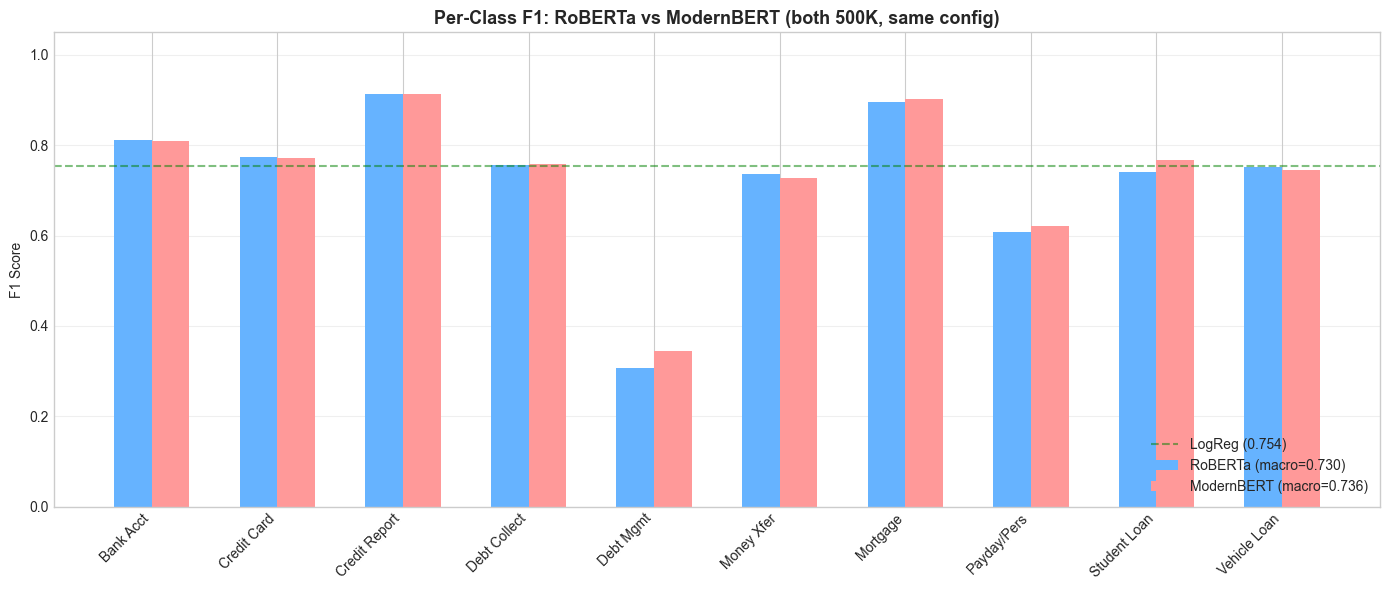

In [20]:
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(n_classes)
width = 0.3

rb_vals = [rob_per_class.get(sl, 0) for sl in short_labels]
ax.bar(x - width/2, rb_vals, width, label=f"RoBERTa (macro={rob_macro:.3f})", color="#66b3ff")
ax.bar(x + width/2, test_per_class, width, label=f"ModernBERT (macro={test_macro_f1:.3f})", color="#ff9999")

ax.axhline(y=0.7543, color="green", linestyle="--", alpha=0.5, label="LogReg (0.754)")
ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=45, ha="right")
ax.set_ylabel("F1 Score"); ax.set_ylim(0, 1.05)
ax.set_title("Per-Class F1: RoBERTa vs ModernBERT (both 500K, same config)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "roberta_vs_modernbert_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

## 9 · Confusion Matrix

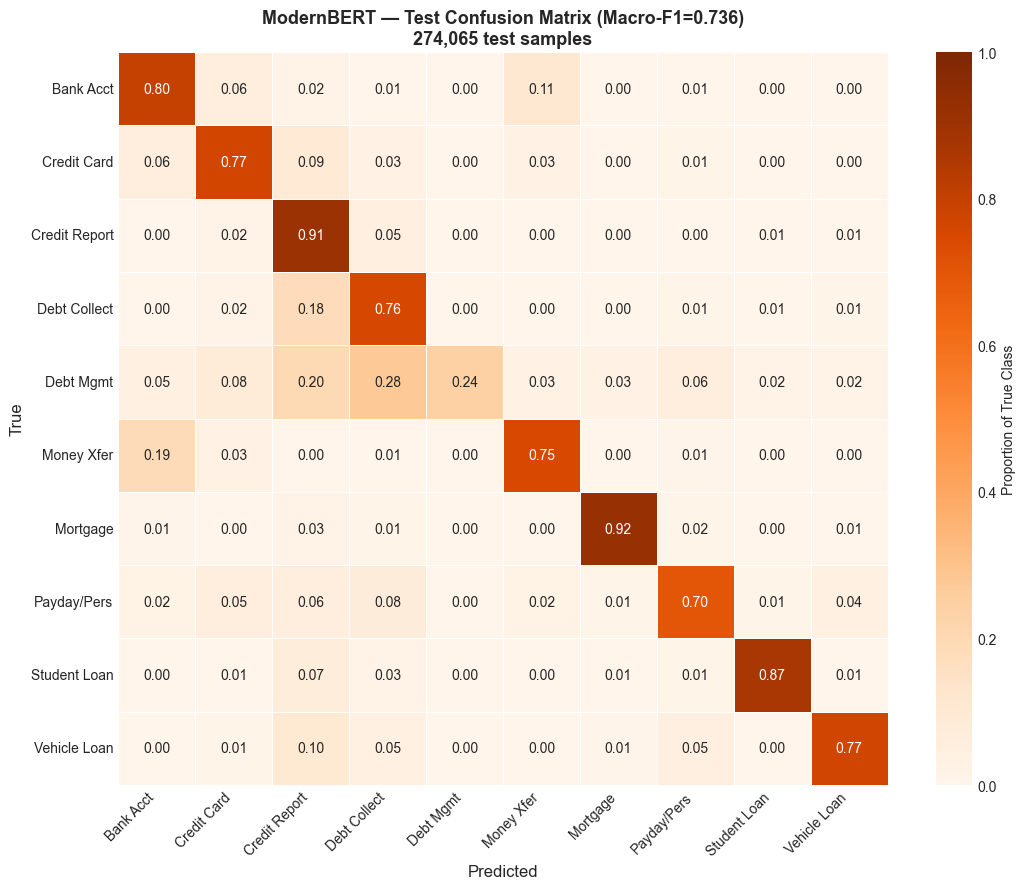

Top confused pairs (off-diagonal > 0.05):
  Debt Mgmt       → Debt Collect     27.7%  🔴
  Debt Mgmt       → Credit Report    20.2%  🔴
  Money Xfer      → Bank Acct        18.8%  🔴
  Debt Collect    → Credit Report    18.2%  🔴
  Bank Acct       → Money Xfer       10.8%  🟡
  Vehicle Loan    → Credit Report    10.3%  🟡
  Credit Card     → Credit Report    9.4%  🟡
  Debt Mgmt       → Credit Card      8.1%  🟡
  Payday/Pers     → Debt Collect     7.6%  
  Student Loan    → Credit Report    7.1%  
  Debt Mgmt       → Payday/Pers      5.8%  
  Payday/Pers     → Credit Report    5.8%  
  Bank Acct       → Credit Card      5.6%  
  Credit Card     → Bank Acct        5.5%  
  Payday/Pers     → Credit Card      5.5%  


In [21]:
cm = confusion_matrix(test_y_true, test_y_pred, normalize="true")

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt=".2f",
    xticklabels=short_labels, yticklabels=short_labels,
    cmap="Oranges", ax=ax, linewidths=0.5, linecolor="white",
    vmin=0, vmax=1.0, cbar_kws={"label": "Proportion of True Class"})
ax.set_xlabel("Predicted", fontsize=12); ax.set_ylabel("True", fontsize=12)
ax.set_title(f"ModernBERT — Test Confusion Matrix (Macro-F1={test_macro_f1:.3f})\n"
    f"{len(test_y_true):,} test samples", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "modernbert_full_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top confused pairs (off-diagonal > 0.05):")
confused = []
for i in range(n_classes):
    for j in range(n_classes):
        if i != j and cm[i, j] > 0.05:
            confused.append((cm[i, j], short_labels[i], short_labels[j]))
confused.sort(reverse=True)
for rate, true_cls, pred_cls in confused:
    severity = "🔴" if rate > 0.15 else "🟡" if rate > 0.08 else ""
    print(f"  {true_cls:15s} → {pred_cls:15s}  {rate:.1%}  {severity}")

## 10 · Training Curves

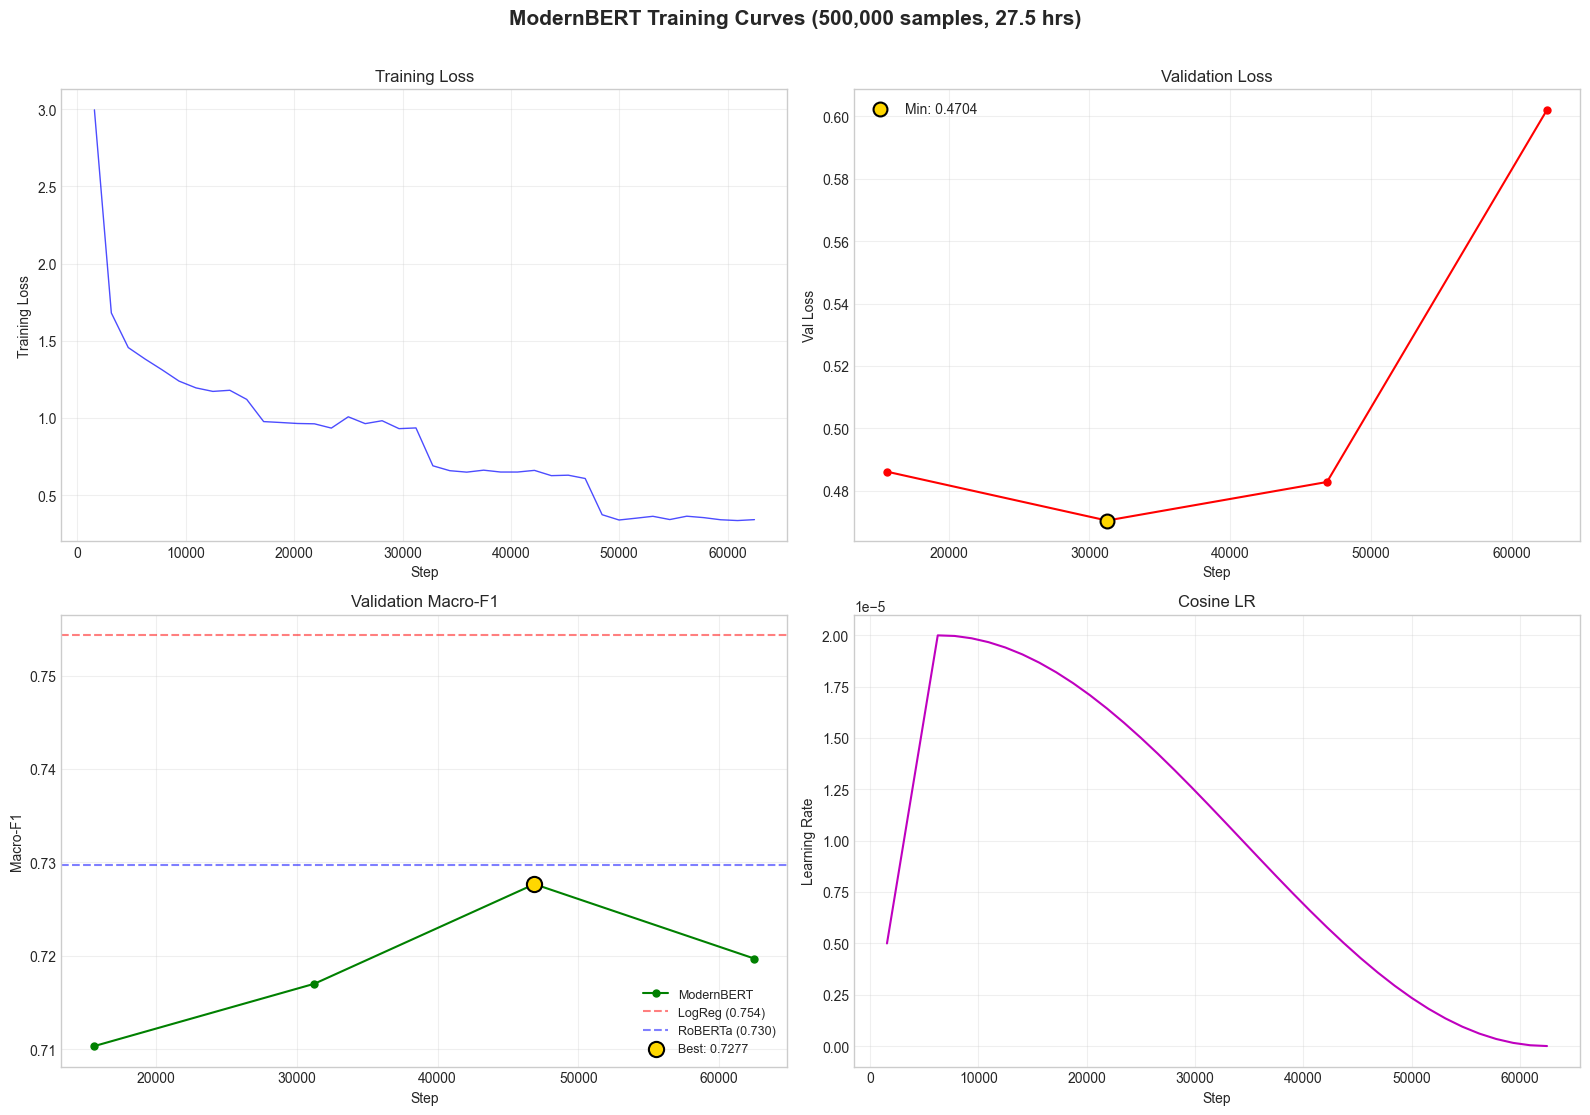


Summary: Best=0.7277 (epoch 3.0), Trained 4.0 epochs


In [22]:
train_logs = [l for l in trainer.state.log_history if "loss" in l and "eval_loss" not in l]
eval_logs  = [l for l in trainer.state.log_history if "eval_macro_f1" in l]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

ax = axes[0, 0]
if train_logs:
    ax.plot([l["step"] for l in train_logs], [l["loss"] for l in train_logs], "b-", alpha=0.7, linewidth=1)
ax.set_xlabel("Step"); ax.set_ylabel("Training Loss"); ax.set_title("Training Loss"); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
if eval_logs:
    e_steps = [l["step"] for l in eval_logs]
    e_losses = [l["eval_loss"] for l in eval_logs]
    ax.plot(e_steps, e_losses, "r-o", markersize=5, linewidth=1.5)
    best_loss_idx = np.argmin(e_losses)
    ax.scatter([e_steps[best_loss_idx]], [e_losses[best_loss_idx]],
              color="gold", s=100, zorder=5, edgecolors="black", linewidths=1.5,
              label=f"Min: {e_losses[best_loss_idx]:.4f}")
    ax.legend()
ax.set_xlabel("Step"); ax.set_ylabel("Val Loss"); ax.set_title("Validation Loss"); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
if eval_logs:
    e_f1s = [l["eval_macro_f1"] for l in eval_logs]
    ax.plot(e_steps, e_f1s, "g-o", markersize=5, linewidth=1.5, label="ModernBERT")
    ax.axhline(y=0.7543, color="red", linestyle="--", alpha=0.5, label="LogReg (0.754)")
    ax.axhline(y=rob_macro, color="blue", linestyle="--", alpha=0.5, label=f"RoBERTa ({rob_macro:.3f})")
    best_f1_idx = np.argmax(e_f1s)
    ax.scatter([e_steps[best_f1_idx]], [e_f1s[best_f1_idx]],
              color="gold", s=120, zorder=5, edgecolors="black", linewidths=1.5,
              label=f"Best: {e_f1s[best_f1_idx]:.4f}")
    ax.legend(loc="lower right", fontsize=9)
ax.set_xlabel("Step"); ax.set_ylabel("Macro-F1"); ax.set_title("Validation Macro-F1"); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
lr_logs = [l for l in trainer.state.log_history if "learning_rate" in l]
if lr_logs:
    ax.plot([l["step"] for l in lr_logs], [l["learning_rate"] for l in lr_logs], "m-", linewidth=1.5)
ax.set_xlabel("Step"); ax.set_ylabel("Learning Rate"); ax.set_title("Cosine LR"); ax.grid(True, alpha=0.3)

plt.suptitle(f"ModernBERT Training Curves ({len(train_dataset):,} samples, {elapsed/3600:.1f} hrs)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "modernbert_full_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

if eval_logs:
    print(f"\nSummary: Best={max(e_f1s):.4f} (epoch {e_steps[np.argmax(e_f1s)]/steps_per_epoch:.1f}), Trained {e_steps[-1]/steps_per_epoch:.1f} epochs")

## 11 · Save All Outputs

In [23]:
best_model_dir = OUTPUT_DIR / "best_model"
trainer.save_model(str(best_model_dir))
tokenizer.save_pretrained(str(best_model_dir))
print(f"✓ Best model saved: {best_model_dir}")

np.save(OUTPUT_DIR / "test_logits.npy",  test_logits)
np.save(OUTPUT_DIR / "test_probs.npy",   test_y_prob)
np.save(OUTPUT_DIR / "test_preds.npy",   test_y_pred)
np.save(OUTPUT_DIR / "test_labels.npy",  test_y_true)
print(f"✓ Test predictions saved — shapes: logits={test_logits.shape}, probs={test_y_prob.shape}")

np.save(OUTPUT_DIR / "val_logits.npy",  val_logits)
np.save(OUTPUT_DIR / "val_probs.npy",   val_y_prob)
np.save(OUTPUT_DIR / "val_preds.npy",   val_y_pred)
np.save(OUTPUT_DIR / "val_labels.npy",  val_y_true)
print(f"✓ Val predictions saved (for NB07 meta-classifier)")

history_path = OUTPUT_DIR / "training_history.json"
with open(history_path, "w") as f:
    json.dump(trainer.state.log_history, f, indent=2)
print(f"✓ Training history saved")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Best model saved: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\modernbert_full\best_model
✓ Test predictions saved — shapes: logits=(274065, 10), probs=(274065, 10)
✓ Val predictions saved (for NB07 meta-classifier)
✓ Training history saved


In [24]:
results = {
    "model":                MODEL_NAME,
    "experiment":           "modernbert_scaled_training",
    "ablation_config":      "5_combined_best (max_len=384) — transferred from RoBERTa",
    "max_seq_len":          MAX_SEQ_LEN,
    "train_samples":        len(train_dataset),
    "full_train_available": full_train_size,
    "val_samples":          len(val_full_dataset),
    "test_samples":         len(test_dataset),
    "val_eval_subsample":   len(val_eval_dataset),
    "max_epochs":           MAX_EPOCHS,
    "epoch_cap_source":     "RoBERTa scouting (peaked epoch 3 → cap 4)",
    "early_stop_patience":  PATIENCE,
    "effective_batch_size":  BATCH_SIZE * GRAD_ACCUM,
    "learning_rate":        LEARNING_RATE,
    "warmup_ratio":         WARMUP_RATIO,
    "precision":            "bf16" if USE_BF16 else "fp16",
    "attention":            "eager (Windows — no Flash Attention 2)",
    "speed_optimisations":  [
        "500K_stratified_subsample",
        "pre-tokenization",
        "dynamic_padding",
        "50K_eval_subsample",
        "full_epoch_eval",
        "epoch_cap_from_roberta_scouting",
    ],

    "best_step":            int(best_step),
    "best_epoch":           round(float(best_epoch), 2),
    "stopped_at_epoch":     round(float(stopped_at), 2),
    "steps_per_epoch":      int(steps_per_epoch),

    "val_macro_f1":         float(val_macro_f1),
    "val_micro_f1":         float(val_micro_f1),
    "val_weighted_f1":      float(val_weighted),
    "val_accuracy":         float(val_accuracy),

    "test_macro_f1":        float(test_macro_f1),
    "test_micro_f1":        float(test_micro_f1),
    "test_weighted_f1":     float(test_weighted),
    "test_accuracy":        float(test_accuracy),
    "test_per_class_f1":    {sl: float(test_per_class[i]) for i, sl in enumerate(short_labels)},

    "confusion_matrix_normalised": cm.tolist(),
    "training_time_hours":  round(elapsed / 3600, 2),
    "training_time_min":    round(elapsed / 60, 1),

    # ── Comparisons (for vlog) ──
    "roberta_test_macro_f1": rob_macro,
    "logreg_macro_f1":       0.7543,
    "delta_vs_roberta":      round(float(test_macro_f1) - rob_macro, 4),
    "delta_vs_logreg":       round(float(test_macro_f1) - 0.7543, 4),

    "vlog_notes": {
        "architecture_comparison": (
            "ModernBERT uses RoPE positional encoding and alternating full/sliding window attention, "
            "versus RoBERTa's absolute learned positions and full attention every layer. "
            "These architectural differences produce different per-class error patterns, "
            "justifying ensemble combination in NB07."
        ),
        "epoch_scouting": (
            f"RoBERTa scouting (NB06a) found optimal epoch at 3. ModernBERT was capped at 4 epochs, "
            f"saving potentially 30+ hours of GPU time versus a naive 10-epoch run."
        ),
    },
}

results_path = OUTPUT_DIR / "modernbert_full_results.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"✓ Results JSON saved: {results_path}")

✓ Results JSON saved: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\modernbert_full\modernbert_full_results.json


In [25]:
del model, trainer
gc.collect()
torch.cuda.empty_cache()
print("✓ GPU memory released.")

✓ GPU memory released.


## 12 · Final Summary

In [26]:
print(f"\n{'═'*70}")
print(f"  NB06b — ModernBERT Training COMPLETE")
print(f"{'═'*70}")
print(f"\n  Model:         {MODEL_NAME}")
print(f"  Train data:    {len(train_dataset):,} / {full_train_size:,} ({len(train_dataset)/full_train_size:.1%})")
print(f"  Epoch cap:     {MAX_EPOCHS} (from RoBERTa scouting)")
print(f"  Best epoch:    {best_epoch:.1f}")
print(f"  Training time: {elapsed/3600:.1f} hours")
print()
print(f"  ┌──────────────────────────────────────────────────────────┐")
print(f"  │  MODEL             Val F1      Test F1     Test Acc     │")
print(f"  ├──────────────────────────────────────────────────────────┤")
print(f"  │  LogReg            —           0.7543      —            │")
print(f"  │  RoBERTa (NB06a)   —           {rob_macro:>6.4f}      —            │")
print(f"  │  ModernBERT (this) {val_macro_f1:>6.4f}      {test_macro_f1:>6.4f}      {test_accuracy:>6.4f}       │")
print(f"  └──────────────────────────────────────────────────────────┘")
print()
print(f"  Next steps:")
print(f"    → NB07: Ensemble (soft voting + learned stacking)")
print(f"           Load test_logits.npy from both:")
print(f"             {ROBERTA_DIR / 'test_logits.npy'}")
print(f"             {OUTPUT_DIR / 'test_logits.npy'}")
print(f"    → The ensemble is our best shot at beating LogReg's 0.754")
print(f"\n{'═'*70}")


══════════════════════════════════════════════════════════════════════
  NB06b — ModernBERT Training COMPLETE
══════════════════════════════════════════════════════════════════════

  Model:         answerdotai/ModernBERT-base
  Train data:    500,000 / 1,813,849 (27.6%)
  Epoch cap:     4 (from RoBERTa scouting)
  Best epoch:    3.0
  Training time: 27.5 hours

  ┌──────────────────────────────────────────────────────────┐
  │  MODEL             Val F1      Test F1     Test Acc     │
  ├──────────────────────────────────────────────────────────┤
  │  LogReg            —           0.7543      —            │
  │  RoBERTa (NB06a)   —           0.7298      —            │
  │  ModernBERT (this) 0.7344      0.7360      0.8476       │
  └──────────────────────────────────────────────────────────┘

  Next steps:
    → NB07: Ensemble (soft voting + learned stacking)
           Load test_logits.npy from both:
             C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\ro